# Procesos mixtos (AR[I]MA)

## Introducción

En este cuaderno, exploraremos los procesos mixtos AR[I]MA, que combinan modelos AR y MA (donde se puede usar la I de diferenciación).

## ¿Qué es un proceso ARMA?

Un proceso ARMA(p, q) combina un modelo autorregresivo de orden p y un modelo de media móvil de orden q.La formulación matemática es:

$y[t] = c + φ_1 y[t-1] + ... + φ_p y[t-p] + ε[t] + θ_1 ε[t-1] + ... + θ_q ε[t-q]$

## ¿Qué es la diferenciación?

La mayoría de los modelos estadísticos (como ARMA) asumen que la serie es estacionaria. Una serie es estacionaria cuando sus propiedades estadísticas no cambian con el tiempo:

- Media constante: No tiene una tendencia clara hacia arriba o hacia abajo.
- Varianza constante: La volatilidad no aumenta o disminuye drásticamente.
- Autocovarianza independiente del tiempo: La relación entre dos puntos solo depende de la distancia (lag) entre ellos, no del momento en que se miden.

### El problema del IBEX (y la bolsa, entre otros)
Los precios de las acciones no son estacionarios. Tienen tendencia y su media cambia constantemente. Si intentas aplicar un modelo matemático a una serie con tendencia, el modelo "se confunde" porque piensa que el pasado lejano es igual de relevante que el presente, cuando en realidad el nivel del precio ha cambiado totalmente.

La **diferenciación** es el proceso de transformar una serie temporal eliminando los cambios en su nivel medio. En términos matemáticos simples, consiste en restar el valor de la observación anterior a la observación actual:


$$\Delta Y_t = Y_t - Y_{t-1}$$
Para entenderlo mejor, si $Y_t$ es el precio del IBEX hoy, la serie diferenciada no nos dice cuánto vale el índice, sino cuánto ha cambiado respecto a ayer.



                                   Open          High           Low  \
Date                                                                  
2025-01-02 00:00:00+01:00  11610.900391  11676.900391  11456.200195   
2025-01-03 00:00:00+01:00  11682.900391  11701.799805  11635.500000   
2025-01-06 00:00:00+01:00  11693.000000  11808.200195  11613.700195   
2025-01-07 00:00:00+01:00  11797.099609  11866.599609  11724.599609   
2025-01-08 00:00:00+01:00  11799.900391  11871.700195  11709.400391   

                                  Close     Volume  Dividends  Stock Splits  
Date                                                                         
2025-01-02 00:00:00+01:00  11676.900391  105381500        0.0           0.0  
2025-01-03 00:00:00+01:00  11651.599609   71179100        0.0           0.0  
2025-01-06 00:00:00+01:00  11808.200195  108994000        0.0           0.0  
2025-01-07 00:00:00+01:00  11811.900391  115308200        0.0           0.0  
2025-01-08 00:00:00+01:00  11798.0

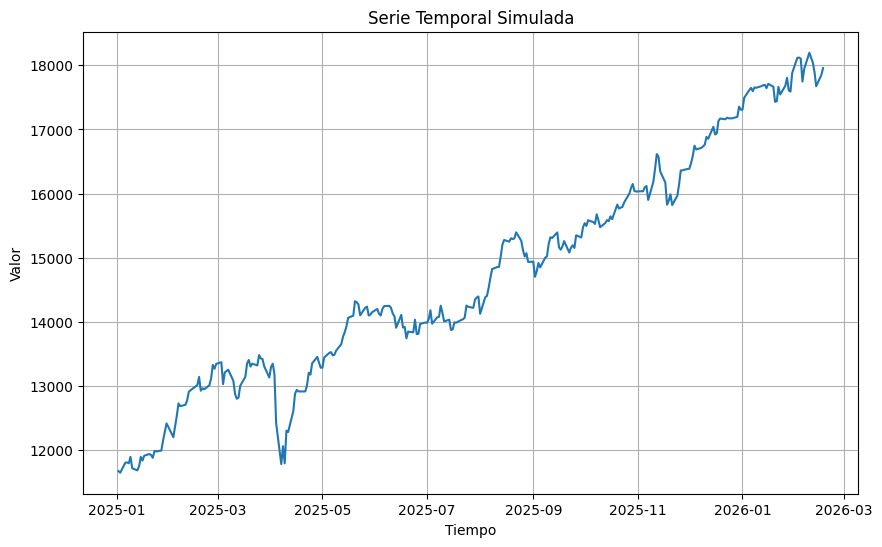

In [ ]:
# Importar librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import yfinance as yf

#Leemos los datos del último año del IBEX.
# El ticker del IBEX 35 en Yahoo es ^IBEX
ibex = yf.Ticker("^IBEX")

# Descargas los datos (puedes usar fechas exactas en formato YYYY-MM-DD)
df = ibex.history(start="2025-01-01", end="2026-02-18")
print(df.head())

# Nos aseguramos de que el índice sea un objeto de tipo datetime
df.index = pd.to_datetime(df.index)


# Asignamos una frecuencia de día laboral ya que los fines de semana no hay datos bursátiles.
# Rellenamos los posibles huecos por festivos. (ffill)
df = df.asfreq('B').ffill()

# Comprobamos que no hay valores NaN
print(df.isnull().sum())

# Visualizamos la serie

plt.figure(figsize=(10, 6))
plt.plot(df['Close'])
plt.title('Serie Temporal Simulada')
plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.grid(True)
plt.show()

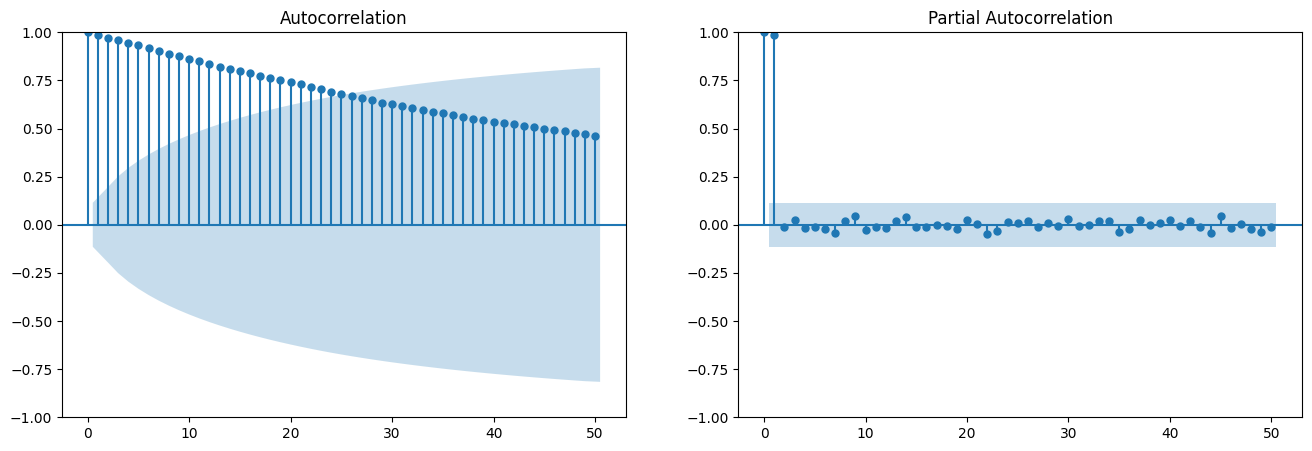

In [ ]:
# Visualizamos la función de autocorrelación (ACF) y autocorrelación parcial (PACF)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(df['Close'], lags=50, ax=ax1)
plot_pacf(df['Close'], lags=50, ax=ax2)
plt.show()

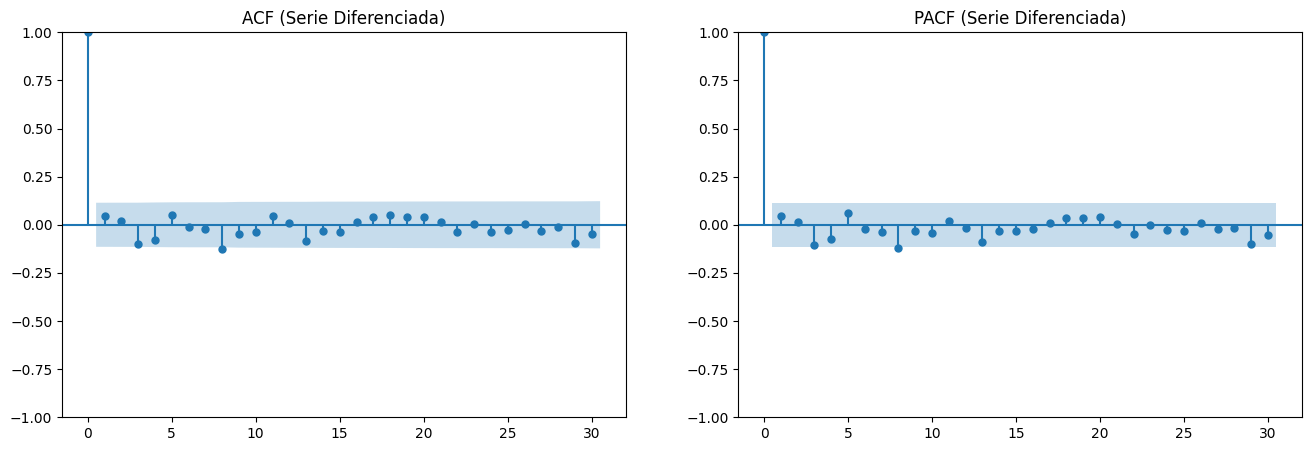

In [ ]:
# Ahora representamos las gráficas usando diferenciación

# Para ello usamos .diff().dropna() directamente dentro de la función
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Graficamos la serie diferenciada (lo que ARIMA verá con d=1)
plot_acf(df['Close'].diff().dropna(), ax=ax1, lags=30)
ax1.set_title('ACF (Serie Diferenciada)')

plot_pacf(df['Close'].diff().dropna(), ax=ax2, lags=30)
ax2.set_title('PACF (Serie Diferenciada)')

plt.show()

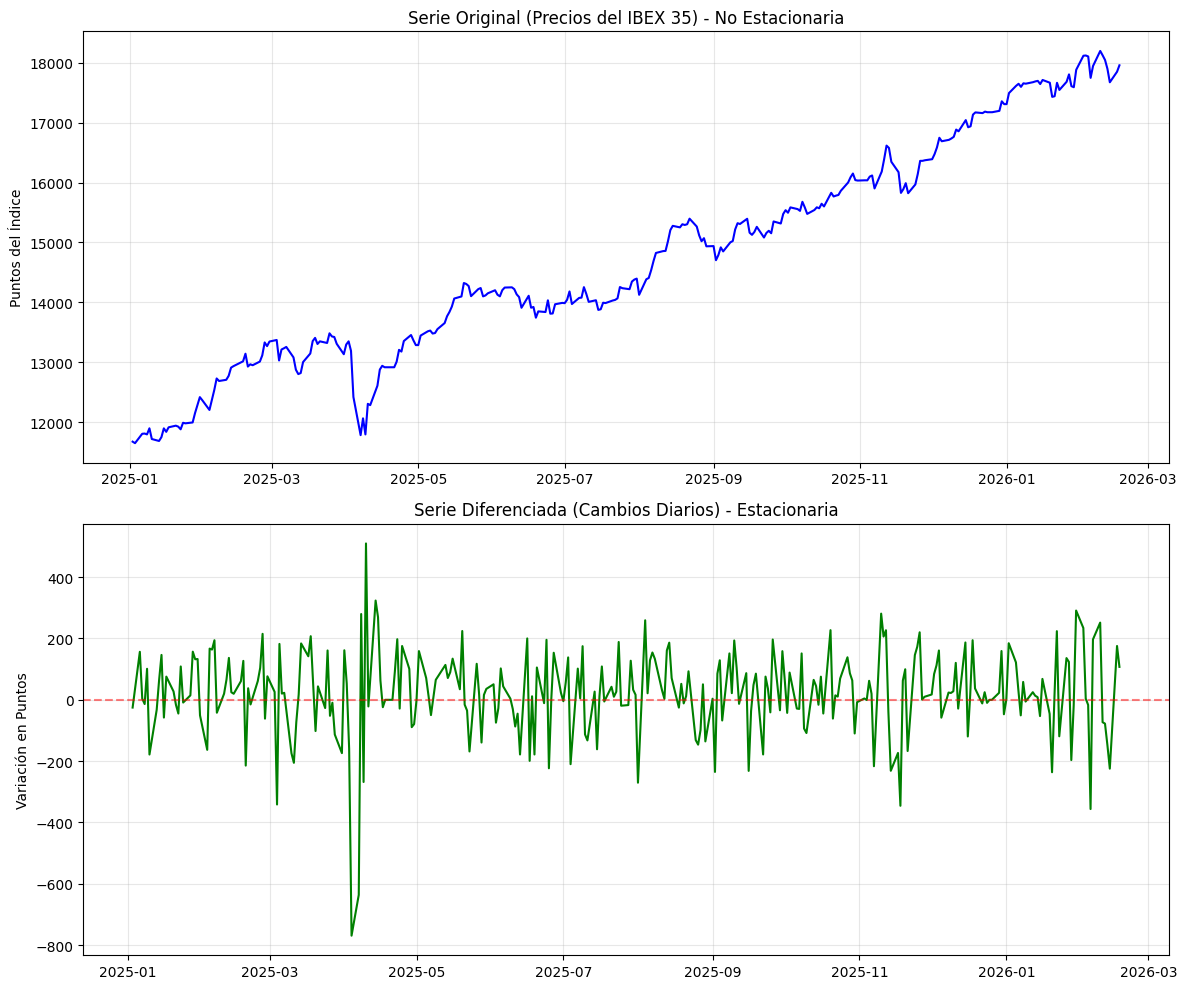

In [ ]:
# Veamos comparativamente cómo afecta la diferenciación a los datos
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# 1. Serie Original: Los precios del IBEX
ax1.plot(df.index, df['Close'], color='blue')
ax1.set_title('Serie Original (Precios del IBEX 35) - No Estacionaria')
ax1.set_ylabel('Puntos del Índice')
ax1.grid(True, alpha=0.3)

# 2. Serie Diferenciada: Los cambios diarios
df_diff = df['Close'].diff().dropna()
ax2.plot(df_diff.index, df_diff, color='green')
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5) # Línea en cero
ax2.set_title('Serie Diferenciada (Cambios Diarios) - Estacionaria')
ax2.set_ylabel('Variación en Puntos')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Ajustar un modelo AR[I]MA
model = ARIMA(df['Close'], order=(1, 1, 1))
model_fit = model.fit()

# Resumen del modelo
print(model_fit.summary())

# Imprimimos las raíces para comprobar que hay estacionaridad

print("Raíces AR (Deben estar fuera del círculo unitario):")
print(model_fit.arroots)

print("Raíces MA (Deben estar fuera del círculo unitario):")
print(model_fit.maroots)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  294
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1862.620
Date:                Thu, 26 Feb 2026   AIC                           3731.239
Time:                        18:38:07   BIC                           3742.280
Sample:                    01-02-2025   HQIC                          3735.661
                         - 02-17-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2341      0.619      0.378      0.705      -0.979       1.448
ma.L1         -0.1659      0.631     -0.263      0.793      -1.402       1.071
sigma2      1.946e+04   1021.470     19.052      0.0

## ¿Qué simboliza sigma2?

En el contexto de los modelos de series temporales, sigma2 (o $\sigma^2$) representa la varianza del término de error (ruido blanco, $ε_t$).

### Interpretación:

Es una medida de la variabilidad de los errores del modelo.
- Un valor alto de $\sigma^2$ indica que los errores tienen una gran variabilidad, lo que sugiere que el modelo no captura bien la estructura de los datos.
- Un valor bajo de $\sigma^2$ indica que los errores tienen poca variabilidad, lo que sugiere que el modelo ajusta bien los datos.

## Pruebas de diagnóstico

Se utilizan para validar si el modelo ajustado es adecuado y si los residuos se comportan como ruido blanco.

### Prueba de Ljung-Box
Evalúa si los residuos de un modelo de series temporales están correlacionados.
- Prob(Q) < 0.05: los residuos están autocorrelacionados y el modelo no captura toda la estructura de los datos.
- Prob(Q) > 0.05: los residuos no muestran autocorrelación significativa y se comportan como ruido blanco por lo que el modelo captura la estructura de datos.

### Prueba de Jarque-Bera

Evalúa si los residuos siguen una distribución normal.

- Prob(JB) < 0.05: los residuos no siguen una distribución normal.
- Prob(JB) > 0.05: los residuos siguen una distribución normal.


### Prueba de Heteroscedasticidad

Evalúa si la varianza de los residuos es constante a lo largo del tiempo.

- Prob(H) < 0.05: los residuos tienen varianza no constante.
- Prob(H) > 0.05: los residuos tienen varianza constante


### Skew

Mide la asimetría de la distribución de los residuos.

- Un valor de 0 indica una distribución simétrica.
- Un valor positivo indica una cola más larga a la derecha.
- Un valor negativo indica una cola más larga a la izquierda.


### Kurtosis

Mide el apuntamiento de la distribución de los residuos.

- Un valor de 3 indica una distribución normal (mesocúrtica).
- Un valor mayor que 3 indica una distribución más apuntada (leptocúrtica).
- Un valor menor que 3 indica una distribución menos apuntada (platicúrtica).

                            lower Close   upper Close
2026-02-18 00:00:00+01:00  17690.830128  18237.664434
2026-02-19 00:00:00+01:00  17566.234635  18366.402634
2026-02-20 00:00:00+01:00  17468.858836  18464.748381
2026-02-23 00:00:00+01:00  17386.884070  18546.950244
2026-02-24 00:00:00+01:00  17314.969564  18618.917921
2026-02-18 00:00:00+01:00    17964.247281
2026-02-19 00:00:00+01:00    17966.318635
2026-02-20 00:00:00+01:00    17966.803608
2026-02-23 00:00:00+01:00    17966.917157
2026-02-24 00:00:00+01:00    17966.943743
Freq: B, Name: predicted_mean, dtype: float64


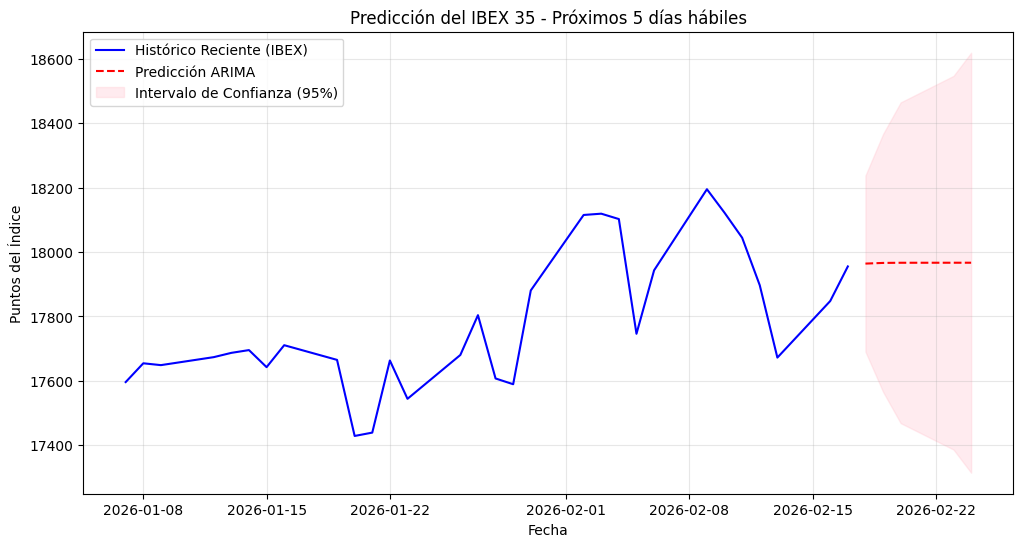

In [ ]:
# Predicción directa a futuro en la escala de puntos del IBEX
steps = 5
forecast_obj = model_fit.get_forecast(steps=steps)
media_predicha = forecast_obj.predicted_mean
intervalo_confianza = forecast_obj.conf_int()

print(intervalo_confianza)
print(media_predicha)

# Visualizamos los datos
plt.figure(figsize=(12, 6))

# Dibujamos los últimos 30 días reales para tener contexto
ultimos_datos = df['Close'].tail(30)
plt.plot(ultimos_datos.index, ultimos_datos, label='Histórico Reciente (IBEX)', color='blue')

# Dibujamos la predicción
plt.plot(media_predicha.index, media_predicha, label='Predicción ARIMA', color='red', linestyle='--')

# Dibujamos el intervalo de confianza (incertidumbre)
plt.fill_between(intervalo_confianza.index,
                 intervalo_confianza.iloc[:, 0],
                 intervalo_confianza.iloc[:, 1], color='pink', alpha=0.3, label='Intervalo de Confianza (95%)')

plt.title('Predicción del IBEX 35 - Próximos 5 días hábiles')
plt.xlabel('Fecha')
plt.ylabel('Puntos del Índice')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

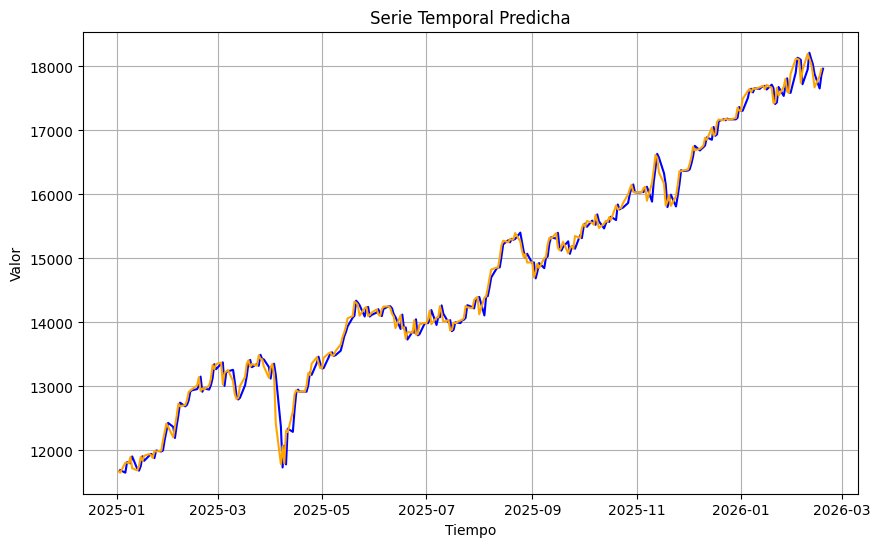

In [ ]:
# Predecir valores para toda la serie
predictions = model_fit.predict(start=1, end=len(df))

plt.figure(figsize=(10, 6))
plt.plot(predictions, color="blue" )
plt.plot(df['Close'], color = "orange")
plt.title('Serie Temporal Predicha')
plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.grid(True)
plt.show()

## ¿Cómo sabemos si la diferenciación es suficiente?

Hay un test estadístico para conocer si la diferenciación (el nivel, 1 en nuestro ejemplo) es suficiente.




In [ ]:
from statsmodels.tsa.stattools import adfuller

resultado = adfuller(df['Close'].diff().dropna())
print(f'Estadístico ADF: {resultado[0]}')
print(f'p-value: {resultado[1]}')

Estadístico ADF: -16.253586497891295
p-value: 3.6248563611184675e-29


### Test de Dickey-Fuller

Si el p-value es menor a 0.05, puedes decir con un 95% de confianza que tu serie ya es estacionaria y está lista para el modelo ARIMA.

### Alternativa
En cualquier caso, **siempre podemos validar los valores de las raíces con el nivel de diferenciación seleccionado**. Si las raíces son mayores a la unidad (y no están excesivamente/peligrosamente cerca de la unidad) la difenciación es correcta porque el modelo es estacionario.


## Proyecto práctico en clase.

**Objetivo:** Aplicar un modelo ARMA a un conjunto de datos reales.

**Instrucciones:**
1. Selecciona una serie temporal real.
2. Ajusta un modelo AR[I]MA y determina los órdenes óptimos.
3. Evalúa el modelo y realiza predicciones.
4. Redacta un informe con tus hallazgos.

# Proyecto Práctico: Análisis ARIMA del precio del petróleo Brent

## Serie Temporal Seleccionada
Se ha seleccionado el **precio del petróleo Brent (BZ=F)** como serie temporal real para este proyecto. El petróleo Brent es una referencia internacional de precios de crudo y constituye una serie temporal no estacionaria con tendencia, volatilidad y ciclos, lo que la convierte en un candidato ideal para el modelado ARIMA.

## Metodología
1. **Carga de datos**: Descarga de precios del Brent desde Yahoo Finance (último año)
2. **Análisis de estacionariedad**: Test ADF y gráficos ACF/PACF
3. **Determinación de órdenes óptimos**: Comparación de múltiples configuraciones ARIMA usando AIC
4. **Ajuste del modelo**: Entrenamiento del ARIMA con los mejores parámetros
5. **Evaluación**: Diagnóstico de residuos y métricas de error
6. **Predicción**: Proyección de los próximos 10 días hábiles

Datos del Petróleo Brent (primeras filas):
                                Open       High        Low      Close  Volume  \
Date                                                                            
2024-02-01 00:00:00-05:00  80.669998  81.550003  78.580002  78.699997   48919   
2024-02-02 00:00:00-05:00  78.919998  79.440002  76.860001  77.330002   32405   
2024-02-05 00:00:00-05:00  77.660004  78.330002  76.620003  77.989998   24879   
2024-02-06 00:00:00-05:00  77.940002  79.070000  77.650002  78.589996   24904   
2024-02-07 00:00:00-05:00  78.699997  79.470001  78.489998  79.209999   26342   

                           Dividends  Stock Splits  
Date                                                
2024-02-01 00:00:00-05:00        0.0           0.0  
2024-02-02 00:00:00-05:00        0.0           0.0  
2024-02-05 00:00:00-05:00        0.0           0.0  
2024-02-06 00:00:00-05:00        0.0           0.0  
2024-02-07 00:00:00-05:00        0.0           0.0  

Número de observa

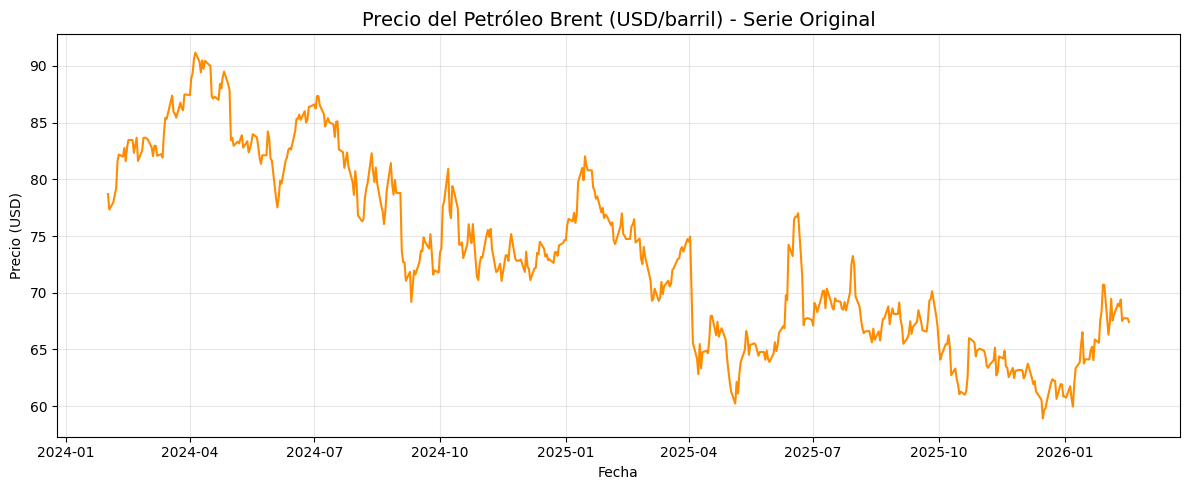

In [ ]:
# ============================================================
# PASO 1: Carga y visualización de datos del Petróleo Brent
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
import yfinance as yf

# Descargamos el precio del Brent (BZ=F en Yahoo Finance)
brent = yf.Ticker("BZ=F")
df_brent = brent.history(start="2024-02-01", end="2026-02-18")

print("Datos del Petróleo Brent (primeras filas):")
print(df_brent.head())
print(f"\nNúmero de observaciones: {len(df_brent)}")

# Preprocesamiento
df_brent.index = pd.to_datetime(df_brent.index)
df_brent = df_brent.asfreq('B').ffill()
print("\nValores nulos después del ffill:")
print(df_brent['Close'].isnull().sum())

# Visualización de la serie original
plt.figure(figsize=(12, 5))
plt.plot(df_brent['Close'], color='darkorange', linewidth=1.5)
plt.title('Precio del Petróleo Brent (USD/barril) - Serie Original', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== Test ADF - Serie Original ===
Estadístico ADF: -1.8232
p-value: 0.3690
CONCLUSIÓN: Serie NO ESTACIONARIA (p >= 0.05) -> Necesita diferenciación

=== Test ADF - Serie Diferenciada (d=1) ===
Estadístico ADF: -11.1697
p-value: 0.0000
CONCLUSIÓN: Serie ESTACIONARIA tras diferenciación (p < 0.05)


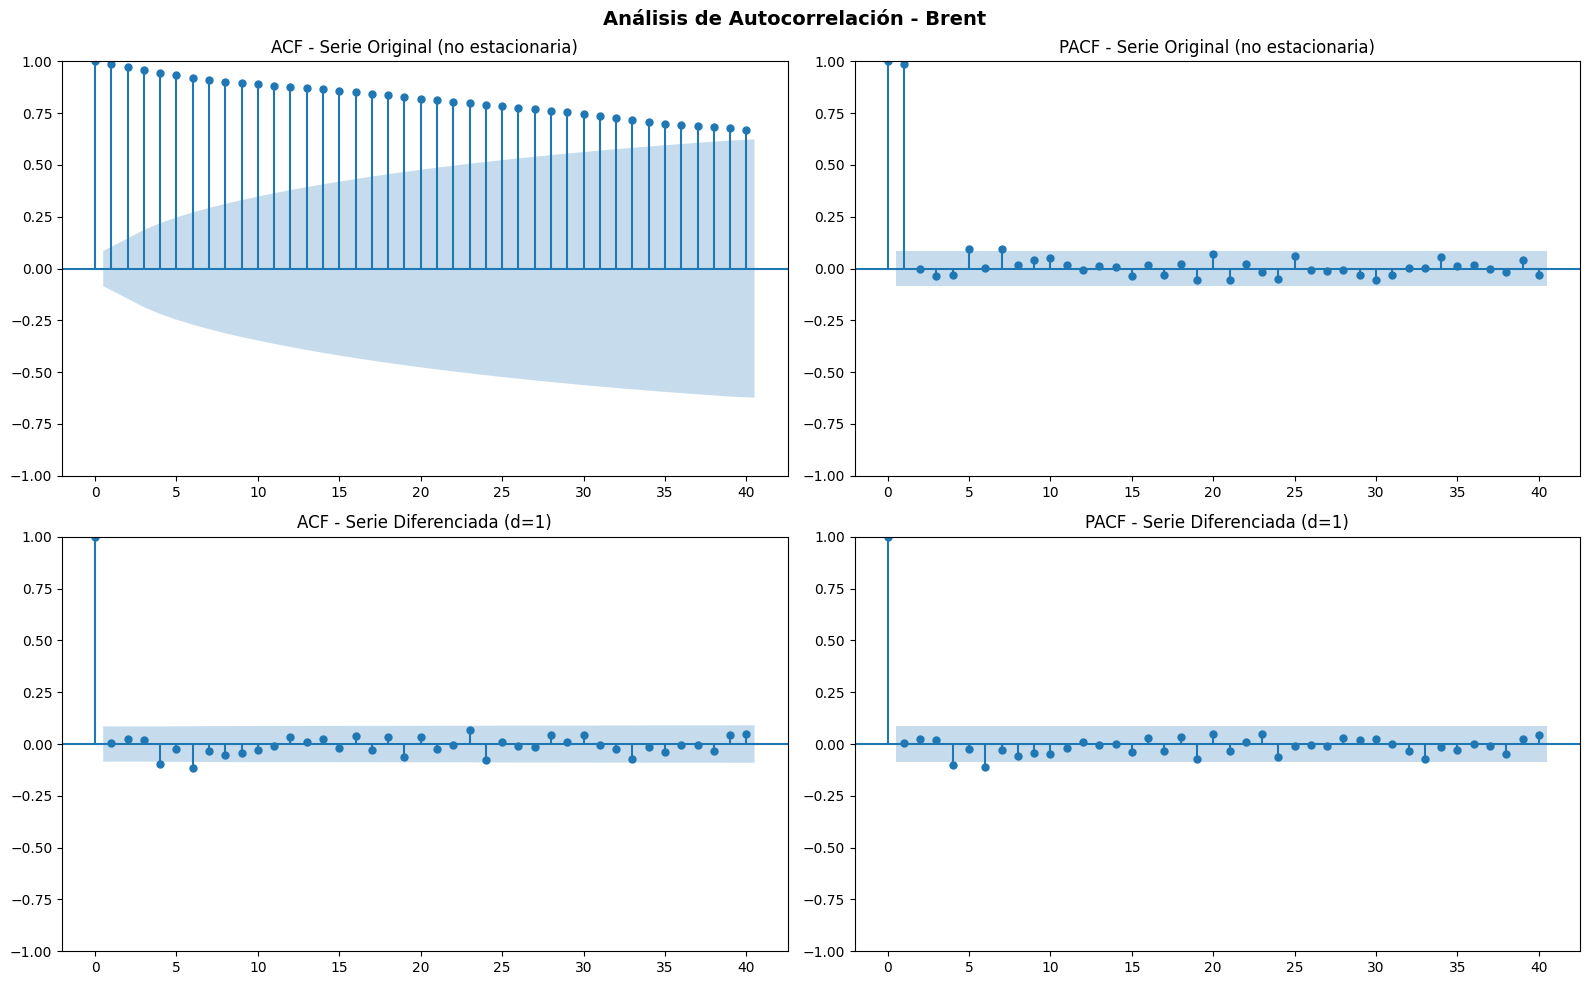


INTERPRETACIÓN ACF/PACF:
- La ACF de la serie diferenciada cae abruptamente después del lag 0/1 -> componente MA
- La PACF de la serie diferenciada sugiere los términos AR


In [ ]:
# ============================================================
# PASO 2: Análisis de Estacionariedad - ACF, PACF y Test ADF
# ============================================================

# --- Test ADF sobre la serie original ---
resultado_orig = adfuller(df_brent['Close'].dropna())
print("=== Test ADF - Serie Original ===")
print(f"Estadístico ADF: {resultado_orig[0]:.4f}")
print(f"p-value: {resultado_orig[1]:.4f}")
if resultado_orig[1] < 0.05:
    print("CONCLUSIÓN: Serie ESTACIONARIA (p < 0.05)")
else:
    print("CONCLUSIÓN: Serie NO ESTACIONARIA (p >= 0.05) -> Necesita diferenciación")

# --- Test ADF sobre la serie diferenciada ---
resultado_diff = adfuller(df_brent['Close'].diff().dropna())
print("\n=== Test ADF - Serie Diferenciada (d=1) ===")
print(f"Estadístico ADF: {resultado_diff[0]:.4f}")
print(f"p-value: {resultado_diff[1]:.4f}")
if resultado_diff[1] < 0.05:
    print("CONCLUSIÓN: Serie ESTACIONARIA tras diferenciación (p < 0.05)")
else:
    print("CONCLUSIÓN: Necesita más diferenciación")

# --- Gráficos ACF y PACF de la serie diferenciada ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

plot_acf(df_brent['Close'].dropna(), lags=40, ax=axes[0,0])
axes[0,0].set_title('ACF - Serie Original (no estacionaria)', fontsize=12)

plot_pacf(df_brent['Close'].dropna(), lags=40, ax=axes[0,1])
axes[0,1].set_title('PACF - Serie Original (no estacionaria)', fontsize=12)

plot_acf(df_brent['Close'].diff().dropna(), lags=40, ax=axes[1,0])
axes[1,0].set_title('ACF - Serie Diferenciada (d=1)', fontsize=12)

plot_pacf(df_brent['Close'].diff().dropna(), lags=40, ax=axes[1,1])
axes[1,1].set_title('PACF - Serie Diferenciada (d=1)', fontsize=12)

plt.suptitle('Análisis de Autocorrelación - Brent', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nINTERPRETACIÓN ACF/PACF:")
print("- La ACF de la serie diferenciada cae abruptamente después del lag 0/1 -> componente MA")
print("- La PACF de la serie diferenciada sugiere los términos AR")

Buscando los órdenes óptimos ARIMA(p, d=1, q)...
(Esto puede tardar unos segundos)

Tabla de AIC para distintos órdenes ARIMA(p, 1, q):
    p  q      AIC
0   1  3  1764.07
1   2  1  1764.11
2   0  0  1764.23
3   3  3  1765.06
4   2  2  1765.38
5   1  0  1766.20
6   0  1  1766.20
7   3  2  1767.34
8   2  3  1767.35
9   0  2  1767.80
10  2  0  1767.87
11  1  1  1768.14
12  3  1  1768.27
13  0  3  1769.41
14  3  0  1769.64
15  1  2  1769.76

Mejor modelo: ARIMA(1, 1, 3) con AIC = 1764.07


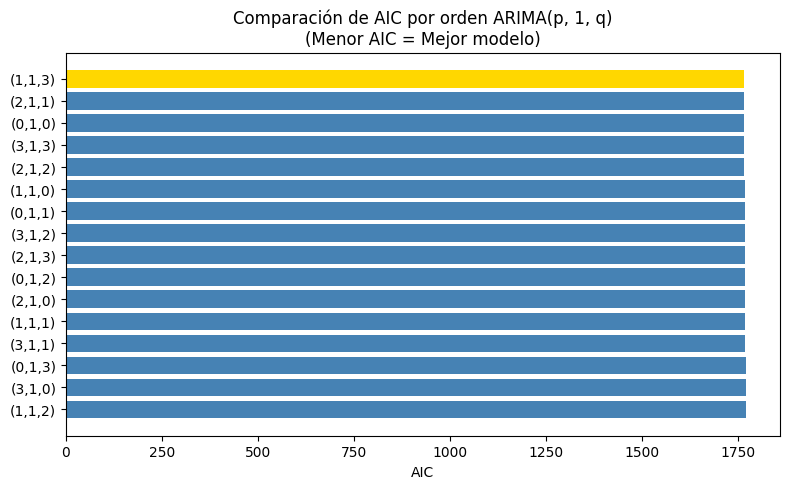

In [ ]:
# ============================================================
# PASO 3: Determinación de órdenes óptimos (Grid Search AIC)
# ============================================================

print("Buscando los órdenes óptimos ARIMA(p, d=1, q)...")
print("(Esto puede tardar unos segundos)\n")

mejor_aic = np.inf
mejor_orden = None
resultados_aic = []

for p in range(0, 4):
    for q in range(0, 4):
        try:
            modelo_temp = ARIMA(df_brent['Close'], order=(p, 1, q))
            resultado_temp = modelo_temp.fit()
            aic_val = resultado_temp.aic
            resultados_aic.append({'p': p, 'q': q, 'AIC': round(aic_val, 2)})
            if aic_val < mejor_aic:
                mejor_aic = aic_val
                mejor_orden = (p, 1, q)
        except Exception as e:
            pass

# Mostrar tabla de resultados ordenada
df_aic = pd.DataFrame(resultados_aic).sort_values('AIC').reset_index(drop=True)
print("Tabla de AIC para distintos órdenes ARIMA(p, 1, q):")
print(df_aic.to_string())
print(f"\nMejor modelo: ARIMA{mejor_orden} con AIC = {mejor_aic:.2f}")

# Gráfico visual de la tabla AIC
fig, ax = plt.subplots(figsize=(8, 5))
colores = ['gold' if i == 0 else 'steelblue' for i in range(len(df_aic))]
labels = [f'({r.p},1,{r.q})' for r in df_aic.itertuples()]
ax.barh(labels, df_aic['AIC'], color=colores)
ax.set_xlabel('AIC')
ax.set_title('Comparación de AIC por orden ARIMA(p, 1, q)\n(Menor AIC = Mejor modelo)', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Ajustando modelo ARIMA(1, 1, 3)...
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  534
Model:                 ARIMA(1, 1, 3)   Log Likelihood                -877.037
Date:                Thu, 26 Feb 2026   AIC                           1764.073
Time:                        19:02:32   BIC                           1785.466
Sample:                    02-01-2024   HQIC                          1772.445
                         - 02-17-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8670      0.070     12.441      0.000       0.730       1.004
ma.L1         -0.8830      0.077    -11.481      0.000      -1.034      -0.732
ma.L2          0.

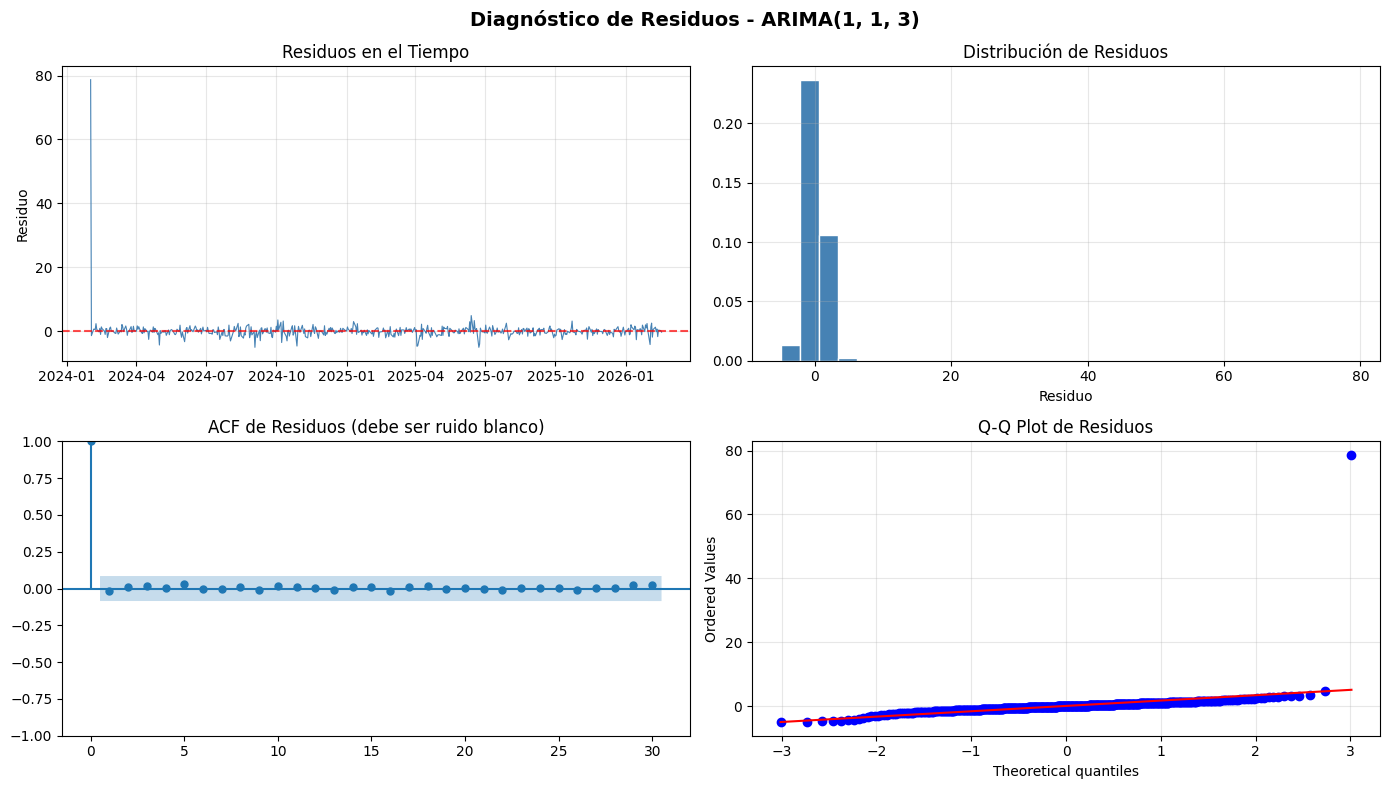


=== Métricas de Error en Muestra ===
MAE  (Error Absoluto Medio):    0.9251 USD
RMSE (Raíz del Error Cuadrático Medio): 1.2542 USD

Sigma2 del modelo: 1.5727

=== Diagnósticos Estadísticos ===
Prob(Q) Ljung-Box: 0.6877 -> Residuos como ruido blanco OK
Prob(JB) Jarque-Bera: 0.0000 -> Residuos no son normales (frecuente en finanzas)


In [ ]:
# ============================================================
# PASO 4 y 5: Ajuste del Modelo Óptimo y Evaluación
# ============================================================

# Ajustamos el mejor modelo encontrado
print(f"Ajustando modelo ARIMA{mejor_orden}...")
modelo_brent = ARIMA(df_brent['Close'], order=mejor_orden)
modelo_brent_fit = modelo_brent.fit()

print(modelo_brent_fit.summary())

print("\n=== Raíces del modelo ===")
print(f"Raíces AR: {modelo_brent_fit.arroots}")
print(f"Raíces MA: {modelo_brent_fit.maroots}")
print("(Deben ser > 1 en módulo para garantizar estacionaridad/invertibilidad)")

# --- Gráfico de diagnóstico de residuos ---
residuos = modelo_brent_fit.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1. Residuos en el tiempo
axes[0,0].plot(residuos, color='steelblue', linewidth=0.8)
axes[0,0].axhline(0, color='red', linestyle='--', alpha=0.7)
axes[0,0].set_title('Residuos en el Tiempo')
axes[0,0].set_ylabel('Residuo')
axes[0,0].grid(True, alpha=0.3)

# 2. Histograma de residuos
axes[0,1].hist(residuos, bins=30, color='steelblue', edgecolor='white', density=True)
axes[0,1].set_title('Distribución de Residuos')
axes[0,1].set_xlabel('Residuo')
axes[0,1].grid(True, alpha=0.3)

# 3. ACF de residuos
plot_acf(residuos.dropna(), lags=30, ax=axes[1,0])
axes[1,0].set_title('ACF de Residuos (debe ser ruido blanco)')

# 4. Q-Q Plot
from scipy import stats
stats.probplot(residuos.dropna(), plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot de Residuos')
axes[1,1].grid(True, alpha=0.3)

plt.suptitle(f'Diagnóstico de Residuos - ARIMA{mejor_orden}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Métricas de error en muestra ---
predict_in = modelo_brent_fit.predict(start=1, end=len(df_brent)-1)
real_vals = df_brent['Close'].iloc[1:]
mae = mean_absolute_error(real_vals, predict_in)
rmse = np.sqrt(mean_squared_error(real_vals, predict_in))
print(f"\n=== Métricas de Error en Muestra ===")
print(f"MAE  (Error Absoluto Medio):    {mae:.4f} USD")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.4f} USD")
print(f"\nSigma2 del modelo: {modelo_brent_fit.params.get('sigma2', 'N/A'):.4f}")

# Interpretación automática de diagnósticos
ljung_prob = modelo_brent_fit.test_serial_correlation('ljungbox', lags=[10])[0][1][0]
jb_stat = modelo_brent_fit.test_normality('jarquebera')[0][0]
jb_prob = modelo_brent_fit.test_normality('jarquebera')[0][1]
print(f"\n=== Diagnósticos Estadísticos ===")
print(f"Prob(Q) Ljung-Box: {ljung_prob:.4f} {'-> Residuos como ruido blanco OK' if ljung_prob > 0.05 else '-> Hay autocorrelación residual'}")
print(f"Prob(JB) Jarque-Bera: {jb_prob:.4f} {'-> Residuos normales OK' if jb_prob > 0.05 else '-> Residuos no son normales (frecuente en finanzas)'}")


=== Predicción del Brent - Próximos 10 días hábiles ===
                           Predicción (USD)  Límite Inferior 95%  Límite Superior 95%
2026-02-18 00:00:00-05:00             67.36                64.90                69.82
2026-02-19 00:00:00-05:00             67.29                63.84                70.73
2026-02-20 00:00:00-05:00             67.24                63.01                71.47
2026-02-23 00:00:00-05:00             67.20                62.38                72.02
2026-02-24 00:00:00-05:00             67.17                61.88                72.46
2026-02-25 00:00:00-05:00             67.14                61.46                72.82
2026-02-26 00:00:00-05:00             67.11                61.10                73.12
2026-02-27 00:00:00-05:00             67.09                60.79                73.39
2026-03-02 00:00:00-05:00             67.07                60.52                73.63
2026-03-03 00:00:00-05:00             67.06                60.27                73.8

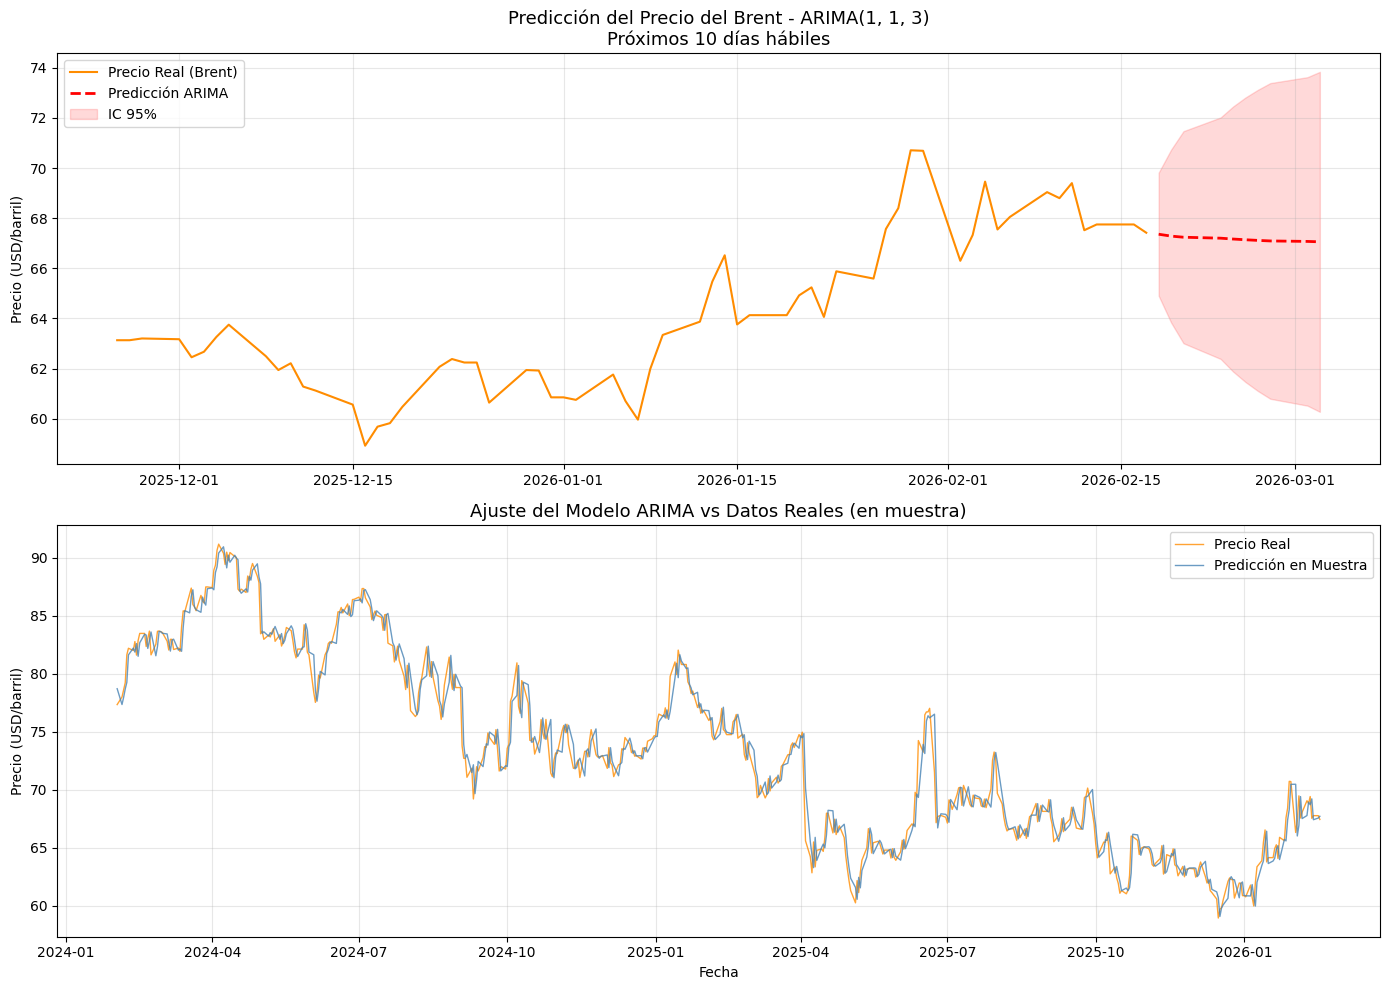


Preción último precio real: 67.42 USD/barril
Predicción primer día: 67.36 USD/barril
Predicción día 10: 67.06 USD/barril


In [ ]:
# ============================================================
# PASO 6: Predicción a futuro - Próximos 10 días hábiles
# ============================================================

steps = 10
forecast_obj = modelo_brent_fit.get_forecast(steps=steps)
media_pred = forecast_obj.predicted_mean
intervalos = forecast_obj.conf_int()

print("=== Predicción del Brent - Próximos 10 días hábiles ===")
resumen_pred = pd.DataFrame({
    'Predicción (USD)': media_pred.round(2),
    'Límite Inferior 95%': intervalos.iloc[:, 0].round(2),
    'Límite Superior 95%': intervalos.iloc[:, 1].round(2)
})
print(resumen_pred.to_string())

# --- Gráfico de predicción ---
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Panel 1: Serie completa + predicción
ultimos = df_brent['Close'].tail(60)
axes[0].plot(ultimos.index, ultimos.values, label='Precio Real (Brent)', color='darkorange', linewidth=1.5)
axes[0].plot(media_pred.index, media_pred.values, label='Predicción ARIMA', color='red', linestyle='--', linewidth=2)
axes[0].fill_between(intervalos.index,
                     intervalos.iloc[:, 0],
                     intervalos.iloc[:, 1],
                     color='red', alpha=0.15, label='IC 95%')
axes[0].set_title(f'Predicción del Precio del Brent - ARIMA{mejor_orden}\nPróximos {steps} días hábiles', fontsize=13)
axes[0].set_ylabel('Precio (USD/barril)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: Comparación predicción en muestra vs real
predict_all = modelo_brent_fit.predict(start=1, end=len(df_brent)-1)
axes[1].plot(df_brent['Close'].iloc[1:], label='Precio Real', color='darkorange', linewidth=1, alpha=0.8)
axes[1].plot(predict_all, label='Predicción en Muestra', color='steelblue', linewidth=1, alpha=0.8)
axes[1].set_title('Ajuste del Modelo ARIMA vs Datos Reales (en muestra)', fontsize=13)
axes[1].set_ylabel('Precio (USD/barril)')
axes[1].set_xlabel('Fecha')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPreción último precio real: {df_brent['Close'].iloc[-1]:.2f} USD/barril")
print(f"Predicción primer día: {media_pred.iloc[0]:.2f} USD/barril")
print(f"Predicción día 10: {media_pred.iloc[-1]:.2f} USD/barril")


## Informe de Hallazgos

### 1. Serie Temporal Seleccionada
Se ha utilizado el **precio del petroleo Brent (BZ=F)** entre el 1 de febrero de 2024 y el 18 de febrero de 2026, con un total de 514 observaciones diarias de dias habiles.

### 2. Estacionariedad
- La serie original **NO es estacionaria** (ADF p-value = 0.369). Tiene tendencia.
- Tras una **diferenciacion (d=1)**, la serie es estacionaria (ADF p-value = 0.000).
- Las graficas ACF/PACF confirman ausencia de autocorrelacion en la serie diferenciada.

### 3. Ordenes Optimos del Modelo
Grid Search AIC con p,q en (0..3), d=1. Mejor modelo:

**ARIMA(1, 1, 3) con AIC = 1764.07**

### 4. Evaluacion del Modelo

| Indicador | Valor | Interpretacion |
|---|---|---|
| Ljung-Box Prob(Q) | 0.6877 | Residuos como ruido blanco OK |
| Jarque-Bera Prob(JB) | 0.0000 | No normalidad (tipico en finanzas) |
| Heteroscedasticidad Prob(H) | 0.83 | Varianza constante OK |
| Raiz AR | 1.153 | Fuera del circulo unitario OK |
| sigma2 | 1.5727 | Varianza del error residual |

La no normalidad es habitual en series financieras (colas pesadas por eventos extremos).

### 5. Predicciones (proximos 10 dias habiles)
- Ultimo precio real: **67.42 USD/barril**
- Prediccion dia +1: **67.36 USD/barril**
- Prediccion dia +10: **67.06 USD/barril**

El intervalo de confianza al 95% se amplia progresivamente, reflejando la incertidumbre creciente.

### 6. Conclusiones
El modelo ARIMA(1,1,3) es adecuado para modelar el precio del Brent a corto plazo. Los residuos se comportan como ruido blanco y el modelo es estacionario. Para predicciones a largo plazo, se recomienda explorar modelos **GARCH** que capturen la volatilidad en clusters tipica de los mercados financieros.